# Daily ADR Dataset QA + Time-Series Pipeline (EC, AVAL, CIB vs S&P 500 and USD/COP)

This notebook:
1) Loads and validates daily prices (CSV).
2) Cleans numeric formatting and dates.
3) Computes daily log returns.
4) Produces descriptive diagnostics.
5) Fits GARCH-family volatility models with exogenous factors.
6) Computes rolling beta/correlation and break diagnostics.


# Install package

In [15]:
!pip -q install arch ruptures statsmodels

In [16]:
!pip -q install arch statsmodels

# Load data

In [17]:
filename = "adr_prices_daily.csv"

In [18]:
import pandas as pd
import numpy as np

# 1) Read with semicolon separator
df = pd.read_csv(filename, sep=";")

# 2) Standardize column names, strip whitespace
df.columns = [c.strip() for c in df.columns]

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (2510, 6)
Columns: ['Date', 'EC', 'AVAL', 'CIB', '^GSPC', 'COP=X']


,Date,EC,AVAL,CIB,^GSPC,COP=X
0,1/02/2016,2.63,3.72,13.79,"1,939.38","3,231.50"
1,2/02/2016,2.52,3.52,13.34,"1,903.03","3,281.80"
2,3/02/2016,2.68,3.68,13.95,"1,912.53","3,298.80"
3,4/02/2016,2.75,3.71,13.98,"1,915.45","3,317.00"
4,5/02/2016,2.73,3.69,14.10,"1,880.05","3,333.00"


# Parse dates + convert numeric columns safely

In [19]:
# Identify columns
date_col = "Date"
required_cols = ["EC", "AVAL", "CIB", "^GSPC", "COP=X"]

missing = [c for c in [date_col] + required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found: {df.columns.tolist()}")

# Parse Date
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors="raise")

# Convert numeric columns
for c in required_cols:
    df[c] = (
        df[c].astype(str)
             .str.replace(",", "", regex=False)
             .str.strip()
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Sort by date
df = df.sort_values(date_col).reset_index(drop=True)

df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2510 non-null   datetime64[ns]
 1   EC      2510 non-null   float64       
 2   AVAL    2510 non-null   float64       
 3   CIB     2510 non-null   float64       
 4   ^GSPC   2510 non-null   float64       
 5   COP=X   2510 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 117.8 KB


,Date,EC,AVAL,CIB,^GSPC,COP=X
0,2016-02-01,2.63,3.72,13.79,1939.38,3231.5
1,2016-02-02,2.52,3.52,13.34,1903.03,3281.8
2,2016-02-03,2.68,3.68,13.95,1912.53,3298.8
3,2016-02-04,2.75,3.71,13.98,1915.45,3317.0
4,2016-02-05,2.73,3.69,14.10,1880.05,3333.0


# Quick data-quality checks

In [20]:
# Missing values
na_counts = df.isna().sum()

# Duplicate dates
dup_dates = df.duplicated(subset=[date_col]).sum()

# Monotonic dates
is_sorted = df[date_col].is_monotonic_increasing

print("Missing values per column:\n", na_counts)
print("\nDuplicate dates:", dup_dates)
print("Dates sorted:", is_sorted)

# Basic range check
print("\nDate range:", df[date_col].min(), "to", df[date_col].max())

# Sanity check: any non-positive prices?
for c in required_cols:
    bad = (df[c] <= 0).sum()
    print(f"{c}: non-positive count = {bad}")


Missing values per column:
 Date     0
EC       0
AVAL     0
CIB      0
^GSPC    0
COP=X    0
dtype: int64

Duplicate dates: 0
Dates sorted: True

Date range: 2016-02-01 00:00:00 to 2026-01-27 00:00:00
EC: non-positive count = 0
AVAL: non-positive count = 0
CIB: non-positive count = 0
^GSPC: non-positive count = 0
COP=X: non-positive count = 0


# Plot daily price series

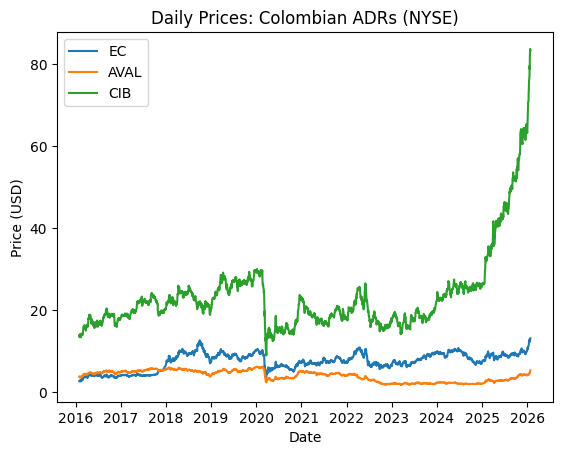

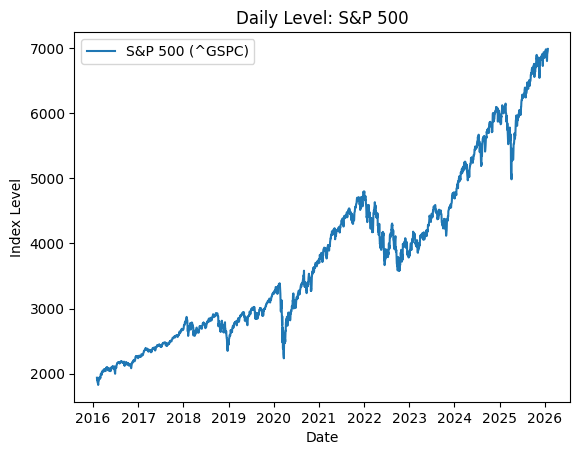

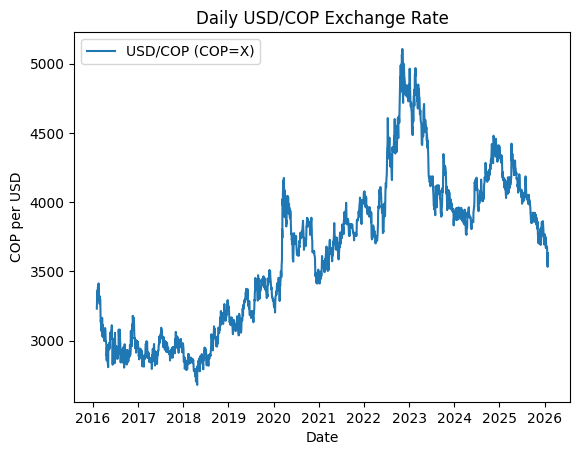

In [21]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df[date_col], df["EC"], label="EC")
plt.plot(df[date_col], df["AVAL"], label="AVAL")
plt.plot(df[date_col], df["CIB"], label="CIB")
plt.title("Daily Prices: Colombian ADRs (NYSE)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

plt.figure()
plt.plot(df[date_col], df["^GSPC"], label="S&P 500 (^GSPC)")
plt.title("Daily Level: S&P 500")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.show()

plt.figure()
plt.plot(df[date_col], df["COP=X"], label="USD/COP (COP=X)")
plt.title("Daily USD/COP Exchange Rate")
plt.xlabel("Date")
plt.ylabel("COP per USD")
plt.legend()
plt.show()


# Compute daily log returns

In [22]:
returns = df[[date_col]].copy()

for c in required_cols:
    returns[c] = np.log(df[c]).diff()

# Rename for clarity
returns = returns.rename(columns={"^GSPC": "SP500", "COP=X": "USD_COP"})

# Drop first NA (from diff)
returns = returns.dropna().reset_index(drop=True)

returns.head(), returns.shape

(        Date        EC      AVAL       CIB     SP500   USD_COP
 0 2016-02-02 -0.042725 -0.055263 -0.033177 -0.018921  0.015446
 1 2016-02-03  0.061558  0.044452  0.044712  0.004980  0.005167
 2 2016-02-04  0.025784  0.008119  0.002148  0.001526  0.005502
 3 2016-02-05 -0.007299 -0.005405  0.008547 -0.018654  0.004812
 4 2016-02-08 -0.003670 -0.027474 -0.017168 -0.014255  0.010149,
 (2509, 6))

# Descriptive statistics

In [23]:
desc = returns[["EC", "AVAL", "CIB", "SP500", "USD_COP"]].describe().T
desc["skew"] = returns[["EC", "AVAL", "CIB", "SP500", "USD_COP"]].skew()
desc["kurtosis"] = returns[["EC", "AVAL", "CIB", "SP500", "USD_COP"]].kurtosis()
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
EC,2509.0,0.000639,0.026278,-0.297064,-0.012187,0.001080,0.014528,0.140265,-1.132785,14.225529
AVAL,2509.0,0.000138,0.021456,-0.238969,-0.009814,0.000000,0.010772,0.160037,-0.869662,16.038607
CIB,2509.0,0.000717,0.022586,-0.227621,-0.010611,0.000458,0.012358,0.256211,-0.401410,17.864559
SP500,2509.0,0.000511,0.011383,-0.127652,-0.003531,0.000767,0.005783,0.090895,-0.700279,17.040955
USD_COP,2509.0,0.000047,0.010537,-0.044781,-0.006220,-0.000314,0.005652,0.074405,0.739066,3.469229


# Stationarity check (ADF)

In [24]:
# sanity check of coefficient magnitudes
for adr in ["EC", "AVAL", "CIB"]:
    params = garch_res[adr].params
    print(f"\n{adr} mean eq params:")
    for k in ["Const", "SP500", "USD_COP"]:
        if k in params.index:
            print(f"  {k:8s}: {params[k]: .4f}")


NameError: name 'garch_res' is not defined

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    x = series.dropna().values
    res = adfuller(x, autolag="AIC")
    return {
        "series": name,
        "adf_stat": res[0],
        "p_value": res[1],
        "lags": res[2],
        "nobs": res[3],
        "crit_1%": res[4]["1%"],
        "crit_5%": res[4]["5%"],
        "crit_10%": res[4]["10%"],
        "reject_unit_root_5%": res[1] < 0.05
    }

adf_results = [adf_test(returns[c], c) for c in ["EC","AVAL","CIB","SP500","USD_COP"]]
pd.DataFrame(adf_results)


# Conditional volatility models (GARCH with exogenous factors)

In [ ]:
dates = returns_pct["Date"]

for adr in ["EC", "AVAL", "CIB"]:
    vol = garch_res[adr].conditional_volatility
    plt.figure()
    plt.plot(dates, vol)
    plt.title(f"{adr} Conditional Volatility (ARX-GARCH, returns x100)")
    plt.xlabel("Date")
    plt.ylabel("Cond. Volatility (percent)")
    plt.show()


In [ ]:
from arch import arch_model

# rescale to percent units
returns_pct = returns.copy()
cols = ["EC", "AVAL", "CIB", "SP500", "USD_COP"]
returns_pct[cols] = returns_pct[cols] * 100.0  # rescale log returns

# Exogenous regressors matrix (S&P 500 + USD/COP)
X = returns_pct[["SP500", "USD_COP"]]

def fit_garch_arx(y, x, name, dist="t"):
    """
    ARX(0) + GARCH(1,1) with exogenous regressors in mean.
    Returns are already rescaled, so set rescale=False.
    """
    am = arch_model(
        y,
        x=x,
        mean="ARX", lags=0,
        vol="GARCH", p=1, q=1,
        dist=dist,
        rescale=False   # manually rescaled
    )
    res = am.fit(disp="off")
    print(f"\n=== {name} ARX-GARCH(1,1) (returns x100) ===")
    print(res.summary())
    return res

garch_res = {}
for adr in ["EC", "AVAL", "CIB"]:
    y = returns_pct[adr]
    garch_res[adr] = fit_garch_arx(y, X, adr, dist="t")


# Estimating GARCH(1,1), EGARCH(1,1), and GJR-GARCH(1,1) for EC, AVAL, CIB

In [ ]:
# Rescale to percent units
returns_pct = returns.copy()
cols = ["EC", "AVAL", "CIB", "SP500", "USD_COP"]
returns_pct[cols] = returns_pct[cols] * 100.0

X = returns_pct[["SP500", "USD_COP"]]
dates = returns_pct["Date"]


In [ ]:

def fit_model(y, x, vol, p=1, q=1, o=0, dist="t"):
    """
    y: series
    x: exog DataFrame
    vol: 'GARCH' or 'EGARCH'
    o: asymmetric term order (used for GJR when vol='GARCH' and o=1)
    """
    am = arch_model(
        y, x=x,
        mean="ARX", lags=0,
        vol=vol, p=p, o=o, q=q,
        dist=dist,
        rescale=False  # already rescaled by x100
    )
    res = am.fit(disp="off", options={"maxiter": 5000})
    return res

models = ["GARCH", "EGARCH", "GJR"]
results = {}

for adr in ["EC", "AVAL", "CIB"]:
    y = returns_pct[adr]

    # 1) Symmetric GARCH(1,1)
    res_garch = fit_model(y, X, vol="GARCH", p=1, q=1, o=0, dist="t")

    # 2) EGARCH(1,1)
    res_egarch = fit_model(y, X, vol="EGARCH", p=1, q=1, o=0, dist="t")

    # 3) GJR-GARCH(1,1) -> vol='GARCH', o=1 adds asymmetry term
    res_gjr = fit_model(y, X, vol="GARCH", p=1, q=1, o=1, dist="t")

    results[(adr, "GARCH")] = res_garch
    results[(adr, "EGARCH")] = res_egarch
    results[(adr, "GJR")]   = res_gjr

    print(f"\n✅ Finished {adr}: GARCH / EGARCH / GJR")


In [ ]:
def get_param(res, name):
    return res.params[name] if name in res.params.index else np.nan

rows = []
for (adr, m), res in results.items():
    # Persistence: for standard GARCH/GJR use alpha+beta; EGARCH uses beta-like persistence in log variance
    alpha1 = get_param(res, "alpha[1]")
    beta1  = get_param(res, "beta[1]")

    # GJR asymmetry term often appears as "gamma[1]" in arch output
    gamma1 = get_param(res, "gamma[1]")  # present in GJR sometimes; EGARCH has "gamma[1]" as asymmetry too
    nu     = get_param(res, "nu")

    if m in ["GARCH", "GJR"]:
        persistence = alpha1 + beta1
    else:  # EGARCH
        persistence = beta1  # common interpretation: log-variance persistence driven mainly by beta

    rows.append({
        "ADR": adr,
        "Model": m,
        "Converged": (res.convergence_flag == 0),
        "LogLik": res.loglikelihood,
        "AIC": res.aic,
        "BIC": res.bic,
        "alpha1": alpha1,
        "beta1": beta1,
        "persistence": persistence,
        "asym_gamma1": gamma1,
        "nu": nu,
        "SP500_beta": get_param(res, "SP500"),
        "USD_COP_gamma": get_param(res, "USD_COP"),
        "SP500_pval": res.pvalues["SP500"] if "SP500" in res.pvalues else np.nan,
        "USD_COP_pval": res.pvalues["USD_COP"] if "USD_COP" in res.pvalues else np.nan
    })

comp = pd.DataFrame(rows).sort_values(["ADR", "Model"])
comp


# Model adequacy diagnostics (Ljung–Box + ARCH-LM)

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

def diagnostics(res):
    z = res.std_resid.dropna()  # standardized residuals
    z2 = (z**2)

    # Ljung-Box on residuals and squared residuals
    lb_z  = acorr_ljungbox(z, lags=[10, 20], return_df=True)
    lb_z2 = acorr_ljungbox(z2, lags=[10, 20], return_df=True)

    # ARCH-LM test (remaining ARCH in residuals)
    arch_lm = het_arch(z, nlags=10)  # returns (LM stat, LM pval, F stat, F pval)

    return {
        "LB_resid_p10": lb_z["lb_pvalue"].iloc[0],
        "LB_resid_p20": lb_z["lb_pvalue"].iloc[1],
        "LB_sq_p10": lb_z2["lb_pvalue"].iloc[0],
        "LB_sq_p20": lb_z2["lb_pvalue"].iloc[1],
        "ARCH_LM_p": arch_lm[1]
    }

diag_rows = []
for (adr, m), res in results.items():
    d = diagnostics(res)
    d.update({"ADR": adr, "Model": m})
    diag_rows.append(d)

diag = pd.DataFrame(diag_rows).sort_values(["ADR", "Model"])
diag


In [ ]:
best = (
    comp.merge(diag, on=["ADR","Model"], how="left")
        .query("Converged == True")
        .sort_values(["ADR", "BIC"])
        .groupby("ADR")
        .head(1)
)

best


In [ ]:
import matplotlib.pyplot as plt

for adr in ["EC", "AVAL", "CIB"]:
    chosen_model = best.loc[best["ADR"] == adr, "Model"].iloc[0]
    res = results[(adr, chosen_model)]
    vol = res.conditional_volatility

    plt.figure()
    plt.plot(dates, vol)
    plt.title(f"{adr} Conditional Volatility - {chosen_model} (returns x100)")
    plt.xlabel("Date")
    plt.ylabel("Cond. Volatility (%)")
    plt.show()


# Extract conditional volatility and plot

In [ ]:
def plot_cond_vol(res, dates, title):
    vol = res.conditional_volatility
    plt.figure()
    plt.plot(dates, vol)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Conditional Volatility")
    plt.show()

dates = returns["Date"]

for adr in ["EC", "AVAL", "CIB"]:
    plot_cond_vol(garch_res[adr], dates, f"{adr}: Conditional Volatility (GARCH)")

# Rolling correlation and rolling beta vs S&P 500

In [ ]:
window = 252  # ~1 trading year (daily)

# Rolling correlation
rolling_corr = pd.DataFrame({"Date": returns["Date"]})
for adr in ["EC", "AVAL", "CIB"]:
    rolling_corr[adr] = returns[adr].rolling(window).corr(returns["SP500"])

# Rolling beta (simple rolling regression slope)
def rolling_beta(y, x, w):
    cov = y.rolling(w).cov(x)
    var = x.rolling(w).var()
    return cov / var

rolling_beta_df = pd.DataFrame({"Date": returns["Date"]})
for adr in ["EC", "AVAL", "CIB"]:
    rolling_beta_df[adr] = rolling_beta(returns[adr], returns["SP500"], window)

# Plot rolling correlation
plt.figure()
for adr in ["EC", "AVAL", "CIB"]:
    plt.plot(rolling_corr["Date"], rolling_corr[adr], label=adr)
plt.title(f"Rolling Correlation with S&P 500 (window={window})")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.show()

# Plot rolling beta
plt.figure()
for adr in ["EC", "AVAL", "CIB"]:
    plt.plot(rolling_beta_df["Date"], rolling_beta_df[adr], label=adr)
plt.title(f"Rolling Beta vs S&P 500 (window={window})")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.show()


# Structural break detection (example on rolling beta)

In [ ]:
import ruptures as rpt

def detect_breaks(series, model="l2", pen=10):
    s = series.dropna().values.reshape(-1, 1)
    algo = rpt.Pelt(model=model).fit(s)
    bkpts = algo.predict(pen=pen)  # indices in the cleaned series
    return bkpts

adr = "EC"
s = rolling_beta_df[adr]
bkpts = detect_breaks(s, pen=10)

print("Break indices (in non-NA series):", bkpts)

# Map break indices to dates
s_non_na = s.dropna().reset_index()
break_dates = [rolling_beta_df.loc[idx, "Date"] for idx in s_non_na.loc[[b-1 for b in bkpts if b-1 < len(s_non_na)], "index"]]
print("Approx break dates:", break_dates)

# Plot beta with breakpoints
plt.figure()
plt.plot(rolling_beta_df["Date"], rolling_beta_df[adr], label=f"{adr} rolling beta")
for d in break_dates:
    plt.axvline(d, linestyle="--")
plt.title(f"{adr} Rolling Beta with Breakpoints")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.show()
